In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [ ]:
master_df = pd.read_csv('data\master_data.csv')

C:\Users\silve\AppData\Local\Temp\ipykernel_16848\2294859533.py:1: DtypeWarning: Columns (0,3,4,6,7,8,9,10,11,12,13,14,15,17,18,19,20,21,22,23,24,25,28,29,30,31,32,34,35,36,38,39,40,41,43,44,45,47,48,49,51,52,53,55,57,58,59,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv('data\master_data.csv')


In [ ]:

person_df = master_df.groupby('customer_id')

column_labels =['transaction_id','customer_id','abm_amount','abm_debit_credit','abm_datetime', 
                'abm_cash_indicator','abm_country', 'abm_province', 'abm_city',
                ]

master_df.columns

Index(['transaction_id', 'customer_id', 'abm_amount', 'abm_debit_credit',
       'abm_datetime', 'abm_cash_indicator', 'abm_country', 'abm_province',
       'abm_city', 'from_abm', 'customer_country', 'customer_province',
       'customer_city', 'customer_gender', 'customer_marital_status',
       'customer_occupation_code', 'customer_income', 'customer_birth_date',
       'customer_onboard_date', 'from_kyc_individual',
       'customer_occupation_title', 'from_kyc_occupation_codes',
       'business_country', 'business_province', 'business_city',
       'business_industry_code', 'business_employee_count', 'business_sales',
       'business_established_date', 'business_onboard_date',
       'from_kyc_smallbusiness', 'business_industry',
       'from_kyc_industry_codes', 'card_amount', 'card_debit_credit',
       'card_datetime', 'card_merchant_category', 'card_ecommerce_indicator',
       'card_country', 'card_province', 'card_city', 'from_card',
       'cheque_amount', 'cheque_debit_c

In [ ]:
abm_df = master_df[['customer_id', 'abm_amount', 'abm_debit_credit', 'abm_datetime']].copy()
abm_df = abm_df.rename(columns={
    'abm_amount': 'amount',
    'abm_debit_credit': 'debit_credit',
    'abm_datetime': 'date'
})
abm_df['transaction_method'] = 'abm'
abm_df = abm_df.dropna(subset=['amount'])
abm_df['date'] = (
    pd.to_datetime(abm_df['date'], utc=True, errors="coerce")
      .dt.tz_convert("America/Toronto")
      .dt.tz_localize(None)
)


card_df = master_df[['customer_id', 'card_amount', 'card_debit_credit', 'card_datetime']].copy()
card_df = card_df.rename(columns={
    'card_amount': 'amount',
    'card_debit_credit': 'debit_credit',
    'card_datetime': 'date'
})
card_df['transaction_method'] = 'card'
card_df = card_df.dropna(subset=['amount'])
card_df['date'] = (
    pd.to_datetime(card_df['date'], utc=True, errors="coerce")
      .dt.tz_convert("America/Toronto")
      .dt.tz_localize(None)
)


cheque_df = master_df[['customer_id', 'cheque_amount', 'cheque_debit_credit', 'cheque_datetime']].copy()
cheque_df = cheque_df.rename(columns={
    'cheque_amount': 'amount',
    'cheque_debit_credit': 'debit_credit',
    'cheque_datetime': 'date'
})
cheque_df['transaction_method'] = 'cheque'
cheque_df = cheque_df.dropna(subset=['amount'])
cheque_df['date'] = (
    pd.to_datetime(cheque_df['date'], utc=True, errors="coerce")
      .dt.tz_convert("America/Toronto")
      .dt.tz_localize(None)
)



eft_df = master_df[['customer_id', 'eft_amount', 'eft_debit_credit', 'eft_datetime']].copy()
eft_df = eft_df.rename(columns={
    'eft_amount': 'amount',
    'eft_debit_credit': 'debit_credit',
    'eft_datetime': 'date'
})
eft_df['transaction_method'] = 'eft'
eft_df = eft_df.dropna(subset=['amount'])
eft_df['date'] = (
    pd.to_datetime(eft_df['date'], utc=True, errors="coerce")
      .dt.tz_convert("America/Toronto")
      .dt.tz_localize(None)
)



emt_df = master_df[['customer_id', 'emt_amount', 'emt_debit_credit', 'emt_datetime']].copy()
emt_df = emt_df.rename(columns={
    'emt_amount': 'amount',
    'emt_debit_credit': 'debit_credit',
    'emt_datetime': 'date'
})
emt_df['transaction_method'] = 'emt'
emt_df = emt_df.dropna(subset=['amount'])
emt_df['date'] = (
    pd.to_datetime(emt_df['date'], utc=True, errors="coerce")
      .dt.tz_convert("America/Toronto")
      .dt.tz_localize(None)
)



westernunion_df = master_df[['customer_id', 'westernunion_amount', 'westernunion_debit_credit', 'westernunion_datetime']].copy()
westernunion_df = westernunion_df.rename(columns={
    'westernunion_amount': 'amount',
    'westernunion_debit_credit': 'debit_credit',
    'westernunion_datetime': 'date'
})
westernunion_df['transaction_method'] = 'westernunion'
westernunion_df = westernunion_df.dropna(subset=['amount'])
westernunion_df['date'] = (
    pd.to_datetime(westernunion_df['date'], utc=True, errors="coerce")
      .dt.tz_convert("America/Toronto")
      .dt.tz_localize(None)
)


wire_df = master_df[['customer_id', 'wire_amount', 'wire_debit_credit', 'wire_datetime']].copy()
wire_df = wire_df.rename(columns={
    'wire_amount': 'amount',
    'wire_debit_credit': 'debit_credit',
    'wire_datetime': 'date'
})
wire_df['transaction_method'] = 'wire'
wire_df = wire_df.dropna(subset=['amount'])
wire_df['date'] = (
    pd.to_datetime(wire_df['date'], utc=True, errors="coerce")
      .dt.tz_convert("America/Toronto")
      .dt.tz_localize(None)
)


transactions_long = pd.concat([abm_df, card_df, cheque_df, eft_df, emt_df,
                               westernunion_df, wire_df], ignore_index=True)


person_df = transactions_long.groupby('customer_id').agg(
    num_transactions = ('amount', 'count'),
    total_amount = ('amount', 'sum'),
    avg_amount = ('amount', 'mean'),
    max_amount = ('amount', 'max'),
    std_amount = ('amount', 'std'),
    num_debit = ('debit_credit', lambda x: (x=='debit').sum()),
    num_credit = ('debit_credit', lambda x: (x=='credit').sum()),
    num_abm = ('transaction_method', lambda x: (x=='abm').sum()),
    num_card = ('transaction_method', lambda x: (x=='card').sum()),
    num_cheque = ('transaction_method', lambda x: (x=='cheque').sum()),
    num_eft = ('transaction_method', lambda x: (x=='eft').sum()),
    num_emt = ('transaction_method', lambda x: (x=='emt').sum()),
    num_westernunion = ('transaction_method', lambda x: (x=='westernunion').sum()),
    num_wire = ('transaction_method', lambda x: (x=='wire').sum())
)

person_df

,num_transactions,total_amount,avg_amount,max_amount,std_amount,num_debit,num_credit,num_abm,num_card,num_cheque,num_eft,num_emt,num_westernunion,num_wire
customer_id,,,,,,,,,,,,,,
SYNID0100000167,18,11562.53,642.362778,3236.46,816.759765,0,0,0,0,1,17,0,0,0
SYNID0100000431,108,22360.92,207.045556,1753.40,332.131472,0,0,14,45,0,20,28,1,0
SYNID0100000485,40,10991.32,274.783000,2264.88,431.253783,0,0,2,19,0,19,0,0,0
SYNID0100000539,150,10409.15,69.394333,1066.48,148.966923,0,0,0,139,0,4,7,0,0
SYNID0100000932,219,175514.88,801.437808,125397.63,8510.250698,0,0,2,189,2,25,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SYNID0200999416,8,475.34,59.417500,241.70,80.820878,0,0,0,8,0,0,0,0,0
SYNID0200999425,9,16480.55,1831.172222,7294.78,2422.614588,0,0,0,0,0,9,0,0,0
SYNID0200999482,20,611931.39,30596.569500,442933.20,97883.731679,0,0,7,1,12,0,0,0,0


In [ ]:
# logistic regression features

activity_features = transactions_long.groupby('customer_id').agg(
    total_transactions=('amount', 'count')
)

money_features = transactions_long.groupby('customer_id').agg(
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    max_amount=('amount', 'max'),
    std_amount=('amount', 'std')
)

debit_credit_features = transactions_long.groupby('customer_id').agg(
    num_debit=('debit_credit', lambda x: (x=='debit').sum()),
    num_credit=('debit_credit', lambda x: (x=='credit').sum())
)

debit_credit_features

channel_features = transactions_long.groupby(['customer_id', 'transaction_method'])['amount'].count().unstack(fill_value=0)

channel_features

transaction_method,abm,card,cheque,eft,emt,westernunion,wire
customer_id,,,,,,,
SYNID0100000167,0,0,1,17,0,0,0
SYNID0100000431,14,45,0,20,28,1,0
SYNID0100000485,2,19,0,19,0,0,0
SYNID0100000539,0,139,0,4,7,0,0
SYNID0100000932,2,189,2,25,1,0,0
...,...,...,...,...,...,...,...
SYNID0200999416,0,8,0,0,0,0,0
SYNID0200999425,0,0,0,9,0,0,0
SYNID0200999482,7,1,12,0,0,0,0


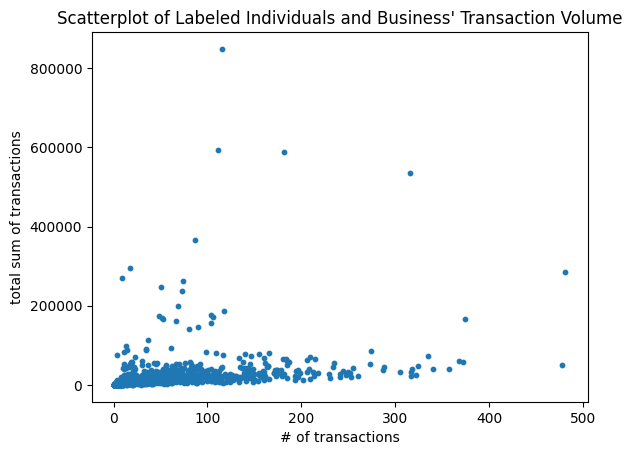

In [ ]:
#quick data visualization on the labeled data
import matplotlib.pyplot as plt

labeled_df = pd.read_csv('data\labels.csv')

labeled_df['customer_id']

labeled_people_df = person_df[person_df.index.isin(labeled_df['customer_id'])]

labeled_people_df = labeled_people_df.merge(
    labeled_df[['customer_id','label']],
    on='customer_id',
    how='left'
)

labeled_people_df

plt.scatter(labeled_people_df['num_transactions'], 
            labeled_people_df['total_amount'],
            s=10 
            )
            
plt.ticklabel_format(style = 'plain', axis= 'y')
plt.xlabel('# of transactions')    
plt.ylabel('total sum of transactions') 
plt.title('Scatterplot of Labeled Individuals and Business\' Transaction Volume')
plt.show()

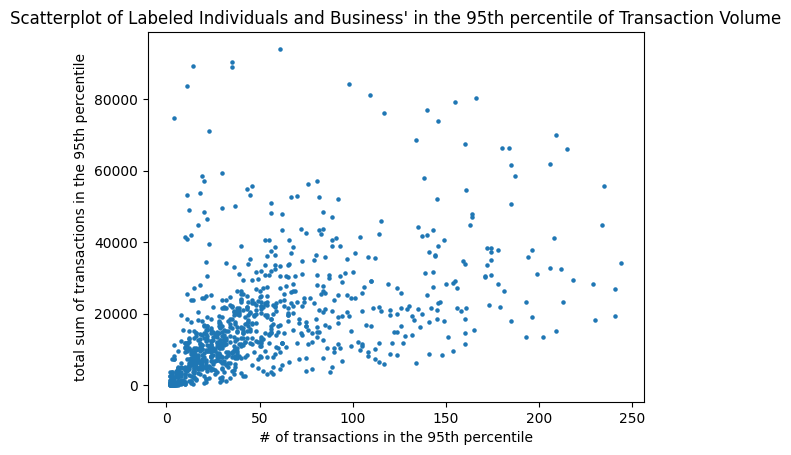

In [ ]:
lower_x = labeled_people_df['num_transactions'].quantile(0.025)
upper_x = labeled_people_df['num_transactions'].quantile(0.975)

lower_y = labeled_people_df['total_amount'].quantile(0.025)
upper_y = labeled_people_df['total_amount'].quantile(0.975)

sum_filter = labeled_people_df[
    (labeled_people_df['num_transactions'] >= lower_x) & (labeled_people_df['num_transactions'] <= upper_x) &
    (labeled_people_df['total_amount'] >= lower_y) & (labeled_people_df['total_amount'] <= upper_y)
    ]

plt.scatter(sum_filter['num_transactions'], sum_filter['total_amount'], s = 5)
plt.xlabel('# of transactions in the 95th percentile')    
plt.ylabel('total sum of transactions in the 95th percentile') 
plt.title('Scatterplot of Labeled Individuals and Business\' in the 95th percentile of Transaction Volume')
plt.show()

C:\Users\silve\AppData\Local\Temp\ipykernel_16848\919267959.py:12: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_invoice_amt = df.pivot_table(


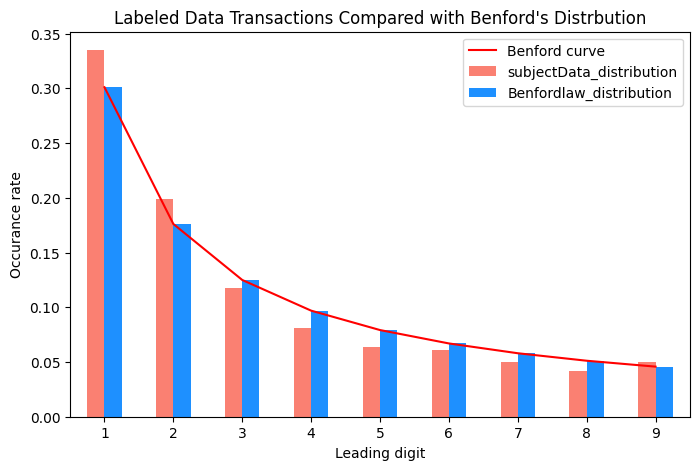

  extract_digit  amount_cad  amount_cad_frequency  subjectData_distribution  \
0             1  6164302.56                   335                     0.335   
1             2  5375879.95                   199                     0.199   
2             3  3114241.83                   118                     0.118   
3             4  1913938.36                    81                     0.081   
4             5  3229667.74                    64                     0.064   
5             6   824406.24                    61                     0.061   
6             7   814066.87                    50                     0.050   
7             8  1703317.17                    42                     0.042   
8             9   641857.45                    50                     0.050   

   Benfordlaw_distribution  
0                 0.301030  
1                 0.176091  
2                 0.124939  
3                 0.096910  
4                 0.079181  
5                 0.066947  
6     

In [ ]:
df = pd.DataFrame() 

df['amount_cad'] = labeled_people_df['total_amount'].copy() 
df['extract_digit'] = df['amount_cad'].astype(str).str[:1] 


first_digit_count = df.pivot_table(
    values = ['amount_cad'],
    index = 'extract_digit', aggfunc= len, fill_value=''  
) 

total_invoice_amt = df.pivot_table(
    values = ['amount_cad'],
    index = 'extract_digit', aggfunc=sum, fill_value=''
)

df2 = total_invoice_amt.merge(first_digit_count, how = 'left',
                              left_on = 'extract_digit',
                              right_index= True,
                              suffixes = ['','_frequency'])

df2['subjectData_distribution'] = df2['amount_cad_frequency']/df2['amount_cad_frequency'].sum()

digits = np.arange(1,10)
benford_df = pd.DataFrame({
    'extract_digit': digits,
    'Benfordlaw_distribution': np.log10(1 + 1/digits)
})

benford_df['extract_digit'] = benford_df['extract_digit'].astype(str)


df2 = df2.merge(benford_df, on='extract_digit', how='left')


fig, ax = plt.subplots(figsize = (8, 5))
df2.reset_index()['Benfordlaw_distribution'].plot(kind = "line", ax = ax, secondary_y = False, color =  'red')
ax.legend(["Benford curve"])
df2.plot(kind = 'bar', x = 'extract_digit', y = ['subjectData_distribution','Benfordlaw_distribution'], 
        ax = ax, color = ['salmon','dodgerblue'], rot = 0)

plt.title('Labeled Data Transactions Compared with Benford\'s Distrbution')
plt.xlabel('Leading digit')
plt.ylabel('Occurance rate')
plt.show()


# print(first_digit_count)
# print(total_invoice_amt)
print(df2)


In [ ]:
labeled_people_df.loc[labeled_people_df['label'] == 1]

labeled_people_df = labeled_people_df.set_index('customer_id')

                 num_transactions  total_amount    avg_amount  max_amount  \
customer_id                                                                 
SYNID0100000485                40      10991.32    274.783000     2264.88   
SYNID0100021236                22       9558.42    434.473636     3170.19   
SYNID0100036671                 1        105.43    105.430000      105.43   
SYNID0100059315                 1       1906.90   1906.900000     1906.90   
SYNID0100060562                15       8678.21    578.547333     2166.00   
...                           ...           ...           ...         ...   
SYNID0200951025                24      25279.15   1053.297917    11113.04   
SYNID0200964390               104     156130.09   1501.250865    16946.12   
SYNID0200970806                18     294139.29  16341.071667   132530.51   
SYNID0200978585                80     141175.31   1764.691375    24795.46   
SYNID0200991884                11      83531.02   7593.729091    51319.53   

In [ ]:
labeled_people_df['std_amount'] = labeled_people_df['std_amount'].fillna(0)

X = labeled_people_df.drop(columns = 'label')

Y = labeled_people_df['label']

X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.3, random_state=21)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)

log_reg = LogisticRegression(random_state = 0).fit(X_train_scaled, y_train)

[[-0.61160864 -0.40592279 -0.17868352 ...  0.67683176 -0.0600223
  -0.12828453]
 [ 0.08051894 -0.0387746  -0.16251212 ...  0.54144607  2.94109261
  -0.12828453]
 [-0.7169324  -0.30038593  0.2505242  ... -0.60933232 -0.0600223
  -0.12828453]
 ...
 [-0.35582236 -0.47158251 -0.35190492 ...  0.20298183 -0.0600223
  -0.12828453]
 [-0.44609987 -0.03265355  0.14277267 ... -0.60933232 -0.0600223
  -0.12828453]
 [ 0.21593521  5.62024368  2.3224029  ... -0.40625378 -0.0600223
  -0.12828453]]


In [ ]:
log_reg.predict(X_train_scaled)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
log_reg.score(X_test_scaled, y_test)

0.9866666666666667

In [ ]:
log_reg.score(X_train_scaled,y_train)

0.99

In [ ]:
# x_full = person_df.drop

X_new = person_df.copy()
X_new['std_amount'] = X_new['std_amount'].fillna(0)

X_new_scaled = scaler.transform(X_new)

predictions = log_reg.predict(X_new_scaled)
probabilities = log_reg.predict_proba(X_new_scaled)[:, 1]

threshold = 0.1
final_predictions = (probabilities >= threshold).astype(int)

# X_new['prediction'] = final_predictions

# print(probabilities)







In [ ]:
feature_names = X_new.columns.tolist()
coefficients = log_reg.coef_[0]
intercept = log_reg.intercept_[0]

contributions = X_new_scaled * coefficients
contrib_df = pd.DataFrame(contributions, columns=feature_names, index=X_new.index)

contrib_df

,num_transactions,total_amount,avg_amount,max_amount,std_amount,num_debit,num_credit,num_abm,num_card,num_cheque,num_eft,num_emt,num_westernunion,num_wire
customer_id,,,,,,,,,,,,,,
SYNID0100000167,0.000671,-0.038996,-0.027847,-0.084345,-0.001059,0.0,0.0,0.024387,-0.083996,-0.029536,-0.032124,0.196978,0.004966,-0.020451
SYNID0100000431,-0.000779,-0.002546,0.090606,-0.138057,-0.002963,0.0,0.0,-0.139195,0.033661,-0.046566,-0.060733,-0.415745,-0.243346,-0.020451
SYNID0100000485,0.000317,-0.040924,0.072174,-0.119533,-0.002574,0.0,0.0,0.001018,-0.034319,-0.046566,-0.051196,0.196978,0.004966,-0.020451
SYNID0100000539,-0.001456,-0.042889,0.128062,-0.162935,-0.003682,0.0,0.0,0.024387,0.279435,-0.046566,0.091848,0.043797,0.004966,-0.020451
SYNID0100000932,-0.002568,0.514425,-0.071133,4.339937,0.029158,0.0,0.0,0.001018,0.410165,-0.012505,-0.108414,0.175095,0.004966,-0.020451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SYNID0200999416,0.000832,-0.076420,0.130776,-0.192806,-0.003950,0.0,0.0,0.024387,-0.063079,-0.046566,0.129993,0.196978,0.004966,-0.020451
SYNID0200999425,0.000816,-0.022395,-0.351331,0.062634,0.005248,0.0,0.0,0.024387,-0.083996,-0.046566,0.044167,0.196978,0.004966,-0.020451
SYNID0200999482,0.000639,1.987549,-8.178607,15.840046,0.380182,0.0,0.0,-0.057404,-0.081382,0.157800,0.129993,0.196978,0.004966,-0.020451


In [ ]:
# Top 3 positive contributors per customer
top_pos = contrib_df.apply(lambda row: row.nlargest(3).index.tolist(), axis=1)

# Top 3 negative contributors (risk reducers)
top_neg = contrib_df.apply(lambda row: row.nsmallest(3).index.tolist(), axis=1)

# Create explanation text
def generate_explanation(row):
    pos_feats = row['top_pos']
    neg_feats = row['top_neg']

    explanation = "Risk increased by: " + ", ".join(pos_feats) + "."
    if neg_feats:
        explanation += " Risk decreased by: " + ", ".join(neg_feats) + "."
    return explanation

# Build DataFrame with explanations
explanations_df = pd.DataFrame({
    'top_pos': top_pos,
    'top_neg': top_neg
})

explanations_df['explanation'] = explanations_df.apply(generate_explanation, axis=1)
explanations_df['customer_id'] = X_new.index



In [ ]:
X_new['prediction'] = final_predictions

final_df = X_new.copy()

final_df['explanation'] = explanations_df['explanation']
final_df['prediction'] = final_predictions
final_df['probabilities'] = probabilities

high_risk_customers  = final_df['prediction']

print(high_risk_customers)

print((final_df['prediction'] == 0).sum())
print((final_df['prediction'] == 1).sum())

customer_id
SYNID0100000167    0
SYNID0100000431    0
SYNID0100000485    0
SYNID0100000539    0
SYNID0100000932    1
                  ..
SYNID0200999416    0
SYNID0200999425    0
SYNID0200999482    1
SYNID0200999834    0
SYNID0200999998    0
Name: prediction, Length: 61410, dtype: int64
58218
3192
